# Project 1: Transaction Success Prediction - Final

AI Disclosure: ChatGPT was used to support concept clarification, wording refinement and visualization formatting. Final code execution, interpretation, and submission decisions were completed independently.

## Problem Definition

This project predicts whether a customer will make a future transaction based on anonymized historical transaction data. Because the target has two possible outcomes, this is a binary classification problem. The main challenge in this project is class imbalance, which makes accuracy alone misleading and requires closer attention to recall and confusion matrix performance.

## Data Collection/Sources

The dataset was provided as a CSV file and loaded into Python using pandas for analysis. It contains anonymized transaction records used to predict whether a customer will complete a future transaction.

The original dataset contained approximately 1,050,000 rows and 104 columns. Because the features are anonymized, early analysis focused on structure, null values, and class balance rather than feature meaning.


Initial setup also included NumPy, Matplotlib, Seaborn, and scikit-learn to prepare for cleaning, model training, and evaluation.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns

from sklearn.metrics import accuracy_score
from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay


In [ ]:
# assign a variable for the url containing the dataframe we will use for this project
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv"
url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv'

In [ ]:
# "Read in" the data set
df = pd.read_csv(url)
df

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

The dataset will be cleaned to remove non-predictive information and reduce missing-data noise before modeling. Columns that do not contribute predictive value, such as unique identifiers or fully empty columns, are removed to reduce noise before modeling.

### Create First Back-up
A backup copy of the original dataframe was created before inspection or cleaning so that preprocessing decisions are easily reversed if needed during later analysis.

In [ ]:
df_back01 = df.copy()
df_back01

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df_back01.copy()

### Initial Data Inspection
Before cleaning, the dataset is inspected to understand structure, column types, missing values, and overall shape. This step helps

identify which variables may interfere with model performance before preprocessing begins.






In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB


In [ ]:
df.describe()

,Unnamed: 0,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
count,1.050000e+06,180000.000000,180000.000000,180000.000000,180000.000000,0.0,180000.000000,0.0,0.0,180000.000000,...,0.0,180000.000000,0.0,180000.000000,0.0,0.0,0.0,0.0,0.0,180000.000000
mean,5.249995e+05,0.100222,7.440715,15.870166,12.735619,NaN,-0.668334,NaN,NaN,1.190419,...,NaN,-3.294620,NaN,-6.727860,NaN,NaN,NaN,NaN,NaN,14.224538
std,3.031090e+05,0.300297,3.021636,3.010492,4.185923,NaN,5.968300,NaN,NaN,5.169343,...,NaN,7.418545,NaN,8.278554,NaN,NaN,NaN,NaN,NaN,0.171058
min,0.000000e+00,0.000000,-2.691700,6.299300,-1.018500,NaN,-22.748700,NaN,NaN,-15.194000,...,NaN,-29.984000,NaN,-35.211700,NaN,NaN,NaN,NaN,NaN,13.729000
25%,2.624998e+05,0.000000,5.160325,13.830400,9.664675,NaN,-4.997500,NaN,NaN,-2.571400,...,NaN,-8.757925,NaN,-12.835875,NaN,NaN,NaN,NaN,NaN,14.098900
50%,5.249995e+05,0.000000,7.350950,15.934600,12.670700,NaN,-0.560300,NaN,NaN,1.194600,...,NaN,-3.170950,NaN,-6.615100,NaN,NaN,NaN,NaN,NaN,14.226800
75%,7.874992e+05,0.000000,9.511125,18.061425,15.837300,NaN,3.632525,NaN,NaN,5.090450,...,NaN,2.043350,NaN,-0.885250,NaN,NaN,NaN,NaN,NaN,14.361800
max,1.049999e+06,1.000000,16.716500,26.079100,26.997600,NaN,18.855400,NaN,NaN,18.471400,...,NaN,21.236400,NaN,18.105600,NaN,NaN,NaN,NaN,NaN,14.743000


In [ ]:
# transpose can help with readability
df.describe( include = "all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1050000.0,NaN,NaN,NaN,524999.5,303109.035663,0.0,262499.75,524999.5,787499.25,1049999.0
ID_code,1050000,1050000,train_1049983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,180000.0,NaN,NaN,NaN,0.100222,0.300297,0.0,0.0,0.0,0.0,1.0
var_0,180000.0,NaN,NaN,NaN,7.440715,3.021636,-2.6917,5.160325,7.35095,9.511125,16.7165
var_1,180000.0,NaN,NaN,NaN,15.870166,3.010492,6.2993,13.8304,15.9346,18.061425,26.0791
...,...,...,...,...,...,...,...,...,...,...,...
var_96,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_97,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_98,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_99,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Use .head() and .tail() to ensure the first few rows and the last few rows do not contain any surprises.

In [ ]:
df.head()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690


.shape gives us the number of rows and columns

In [ ]:
df.shape

(1050000, 104)

In [ ]:
df['target'].isnull().sum()

np.int64(870000)

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
var_3,1050000
var_16,1050000
var_12,1050000
var_11,1050000
var_9,1050000
...,...
var_88,870000
var_94,870000
var_100,870000
Unnamed: 0,0


We also need to search for columns that are only unique identifiers, which are unnecessary for our model.

In [ ]:
nunique = df.nunique().sort_values( ascending = False )
nunique

,0
Unnamed: 0,1050000
ID_code,1050000
var_52,137280
var_86,134537
var_94,131746
...,...
var_93,0
var_96,0
var_97,0
var_98,0


### Remove Identifier Column

The unique identifier columns were removed because it distinguishes rows but does not help predict future transactions.

In [ ]:
drop_ids = nunique[ nunique == df.shape[0] ].index
drop_ids

Index(['Unnamed: 0', 'ID_code'], dtype='object')

In [ ]:
df.drop( columns = drop_ids, inplace = True)
df

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,-1.9254,6.4760,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,-6.8112,7.3226,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,1.6614,6.1486,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Drop Fully Null Columns

Columns containing only null values were removed because they provide no usable information to the model.

In [ ]:
df.isna().sum().sort_values(ascending=False).mul(100).div(len(df))

,0
var_3,100.000000
var_11,100.000000
var_9,100.000000
var_10,100.000000
var_6,100.000000
...,...
var_88,82.857143
var_86,82.857143
var_85,82.857143
var_94,82.857143


In [ ]:
df.dropna(axis=1, how="all", inplace=True)
df

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689
1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df['target'].isnull().sum()

np.int64(870000)

### Drop Rows with Excessive Missing Values
Rows with only null values are removed to improve data quality before training.

In [ ]:
df[df.isnull().all(axis=1)].index

Index([      0,       1,       2,       4,       6,       7,       8,       9,
            10,      12,
       ...
       1049984, 1049985, 1049986, 1049987, 1049989, 1049991, 1049992, 1049994,
       1049996, 1049998],
      dtype='int64', length=870000)

In [ ]:
df.dropna(how="all", inplace=True)
df

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


### Verify Cleaned Dataset

The cleaned dataset is reviewed again to confirm that unnecessary columns and invalid rows are removed.

In [ ]:
# The target column is now free of null values
df['target'].isnull().sum()

np.int64(0)

In [ ]:
df.shape

(180000, 51)

## Exploratory Data Analysis

Exploratory analysis was used to evaluate how well the data fit core Gaussian Naive Bayes assumptions before modeling. Histograms showed whether features were approximately normally distributed, while the correlation matrix helped identify whether variables were strongly related, since Gaussian Naive Bayes assumes features contribute largely independent evidence toward classification.

### Feature Distribution Review

Histograms were generated across variables to check whether distributions aligned reasonably with Gaussian assumptions.

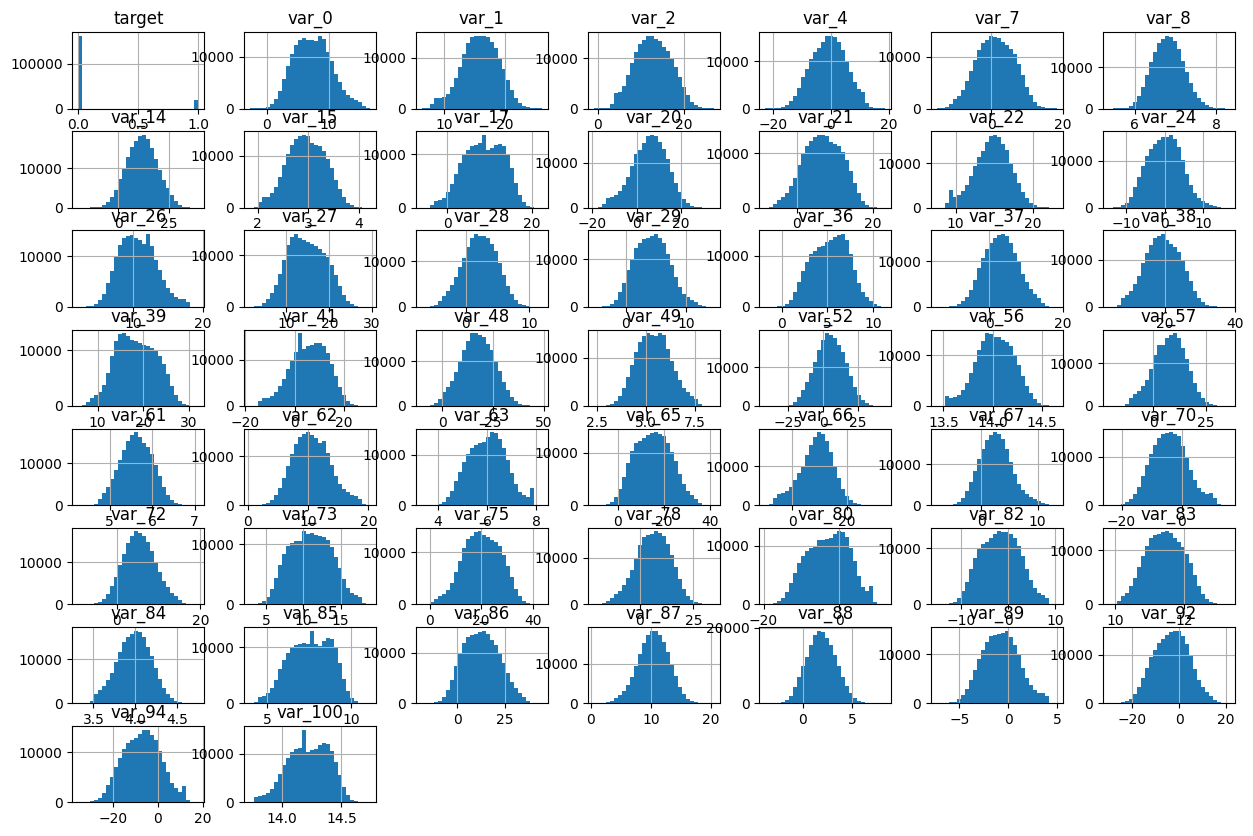

In [ ]:
df.iloc[1:, :52].hist(figsize=(15, 10), bins=30);

In [ ]:
df["target"].unique()

array([0., 1.])

### Feature Correlation Review

In [ ]:
corr = df.corr()
corr

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
target,1.000000,0.045506,-0.051718,-0.046433,0.041593,-0.041987,0.052457,0.045281,-0.057373,-0.054375,...,-0.052324,-0.053733,-0.042073,0.047543,-0.063871,-0.042765,0.059306,0.040520,0.049072,-0.047005
var_0,0.045506,1.000000,-0.000892,-0.000225,-0.000269,-0.001320,0.002949,0.002901,-0.007758,-0.002799,...,-0.004960,-0.005451,-0.000716,0.004577,-0.004664,-0.001088,0.000236,0.001668,0.001837,0.001475
var_1,-0.051718,-0.000892,1.000000,0.006064,-0.000821,0.000783,-0.007127,-0.006180,-0.002585,-0.001663,...,0.004265,0.002411,0.001484,-0.003859,-0.000485,0.003141,-0.006188,0.000071,-0.003682,0.003964
var_2,-0.046433,-0.000225,0.006064,1.000000,-0.003427,-0.000108,-0.001809,-0.002786,-0.001177,0.006360,...,0.004890,0.002240,0.001980,-0.001161,0.003921,0.002087,-0.004422,-0.003418,-0.001565,0.002418
var_4,0.041593,-0.000269,-0.000821,-0.003427,1.000000,-0.002750,0.003347,0.001377,-0.004732,-0.001814,...,0.000657,-0.005267,-0.004266,-0.004179,-0.004211,-0.002330,0.000254,0.001090,-0.000468,-0.002807
var_7,-0.041987,-0.001320,0.000783,-0.000108,-0.002750,1.000000,-0.003199,-0.003588,0.002329,0.004282,...,-0.000412,0.003262,0.002574,-0.001824,0.001186,0.002811,0.001306,0.000236,-0.000568,0.004575
var_8,0.052457,0.002949,-0.007127,-0.001809,0.003347,-0.003199,1.000000,0.003472,-0.003858,-0.002727,...,-0.008394,-0.004254,-0.002446,0.001117,-0.003713,-0.003929,0.003837,0.003422,0.003204,0.000821
var_14,0.045281,0.002901,-0.006180,-0.002786,0.001377,-0.003588,0.003472,1.000000,-0.007115,-0.004249,...,-0.002214,-0.002179,-0.003054,-0.000160,-0.000504,-0.004046,0.003136,0.005715,0.001501,-0.000106
var_15,-0.057373,-0.007758,-0.002585,-0.001177,-0.004732,0.002329,-0.003858,-0.007115,1.000000,0.002467,...,0.000581,0.006633,0.004569,-0.001573,0.003251,0.003066,-0.001541,-0.003719,-0.002825,0.004247
var_17,-0.054375,-0.002799,-0.001663,0.006360,-0.001814,0.004282,-0.002727,-0.004249,0.002467,1.000000,...,0.005578,0.001237,0.000210,-0.002714,0.004149,-0.002182,-0.002642,-0.001968,-0.004100,-0.000822


In [ ]:
df_success = df[df["target"] == 1].copy()
df_fail = df[df["target"] == 0].copy()

In [ ]:
df_success

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
57,1.0,8.9078,12.1321,9.4707,-5.8102,0.4521,7.1264,15.6935,2.6980,4.3336,...,11.2059,4.0237,5.8905,12.4865,10.1419,2.3370,-3.1553,-12.6928,-3.0833,14.1895
125,1.0,6.2143,20.0990,23.5009,-0.8917,-3.9167,6.6863,21.4162,2.8672,6.4550,...,10.8110,3.9190,7.4971,35.7428,9.6149,2.2257,-0.5949,-9.4101,-15.6555,14.4514
151,1.0,8.9083,12.1117,18.0359,-4.9628,10.1135,6.8962,11.4553,2.6735,2.1990,...,11.6326,3.9193,5.0366,37.1453,17.0341,0.9987,-3.0163,-1.5409,-7.6389,14.1725
155,1.0,6.5612,13.9638,5.1980,12.1092,8.4874,6.4781,16.9541,2.0573,5.5008,...,11.2981,4.1316,7.2193,-1.8139,1.8190,2.5720,0.6780,6.4045,1.1754,14.1347
302,1.0,4.4616,9.7572,12.9317,7.6485,0.6382,5.8025,22.4577,3.0906,16.2501,...,11.5449,4.0001,9.0639,11.8805,9.4678,1.0561,-0.2107,9.8815,-2.9328,14.0933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049783,1.0,3.1286,15.0751,21.3962,11.3161,-10.0493,6.3525,25.4931,2.6605,7.2691,...,10.9172,4.1120,4.6540,9.1151,7.8918,2.5714,1.0304,5.2623,-0.6030,14.1993
1049818,1.0,15.2934,17.5721,5.8949,-4.0233,5.8840,7.3892,11.3932,2.7062,6.9666,...,11.1665,3.9652,7.4879,-7.9060,10.7256,0.8941,-3.5967,6.3976,0.5778,14.5067
1049978,1.0,7.4751,17.0314,5.0834,-1.5220,-2.4913,6.7953,10.7764,2.9049,2.6145,...,11.6605,3.6716,8.5965,19.2145,8.2747,4.0945,-3.0127,2.9477,-2.3696,14.4122
1049983,1.0,5.2746,14.4095,17.7709,-2.9855,-0.8515,6.5097,11.5599,2.9677,0.0507,...,11.8870,3.7776,6.9876,3.3482,9.7469,-0.3425,-2.5684,14.5286,-5.4146,14.4388


In [ ]:
df_fail

,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049988,0.0,10.7453,13.3217,15.4001,4.0421,1.3116,6.3990,13.9387,2.9627,13.6450,...,11.6062,3.9162,9.7054,15.2405,10.6480,0.5372,0.4014,4.8258,-8.2380,14.0328
1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


## Data Processing: Prep for Modeling

### Separate Features and Target

The dataset was divided into predictors and the target variable, where the target indicates whether a future transaction occurred.

In [ ]:
features = df.drop(columns=["target"]).copy()
features

,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,var_17,var_20,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,2.8817,11.6975,0.5878,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,2.2225,7.2218,6.5456,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,3.4990,4.2892,18.7893,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,2.8910,8.2374,1.1400,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,3.2771,12.6446,7.8002,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,3.0732,11.0135,3.1549,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,2.4057,18.2729,3.9661,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,2.4579,14.7175,3.8858,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,2.5439,10.2936,2.0014,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [ ]:
target_column = df["target"].copy()
target_column

,target
3,0.0
5,0.0
11,0.0
15,0.0
19,0.0
...,...
1049990,0.0
1049993,0.0
1049995,1.0
1049997,0.0


In [ ]:
print("Features shape:", features.shape)
print("Target shape:", target_column.shape)

Features shape: (180000, 50)
Target shape: (180000,)


### Train-Test Split

The data was divided into training and testing sets so the model could learn patterns on one portion and be evaluated on unseen data.

In [ ]:
# Divide the two dataframes, target and features, into training and testing subsets.
features_train, features_test, target_train, target_test = train_test_split(
    features,
    target_column,
    test_size=0.20,
    random_state=42,
    stratify=target_column
    )

In [ ]:
print(features_train.shape)
print(features_test.shape)

(144000, 50)
(36000, 50)


### Initialize Gaussian Naive Bayes

Gaussian Naive Bayes estimates class probabilities by assuming each feature contributes independently and follows an approximately Gaussian distribution.

In [ ]:
gnb = GaussianNB()

### Train model on Training Set

In [ ]:
# Train the GNB model using the training subset of the dataset
gnb.fit(features_train, target_train);

### Generate Predicitons on Test Set

In [ ]:
# Generate predictions using the test set
target_pred = gnb.predict(features_test)
print(target_pred[:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Predictions were generated on the test set so model performance could be compared against the true target values.

## Initial Model Evaluation

The initial model was evaluated using accuracy, cross-validation, and confusion matrix results to determine how well it performed before addressing class imbalance.

#### Report accuracy

In [ ]:
accuracy = accuracy_score(target_test, target_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9116944444444445


The initial Gaussian Naive Bayes model achieved approximately 91% accuracy on the test set. However, because the target classes are imbalanced, accuracy alone does not fully describe model performance.

### Cross-validation

In [ ]:
#Perform a crosss-validation loop to calculate the accuracy of model

n = 100
results = np.zeros(n)

for i in range(n):
## TSS
  features_train, features_test, target_train, target_test = train_test_split(features, target_column, test_size=.20)

## model
  gnb = GaussianNB()

## fit
  gnb.fit(features_train, target_train)

## prediction
  target_pred = gnb.predict(features_test)

## performance
  results[i] = 1-(target_test - target_pred).abs().mean()

### Histogram for Cross-Validation

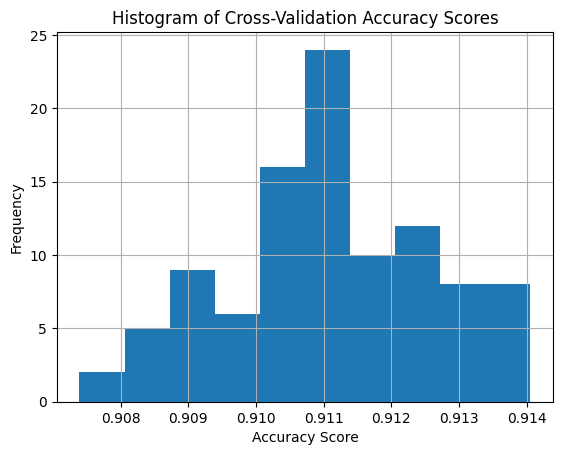

In [ ]:
pd.Series(results).hist()

plt.xlabel('Accuracy Score')
plt.ylabel('Frequency')
plt.title('Histogram of Cross-Validation Accuracy Scores')
plt.show()

In [ ]:
# Report that accuracy.
results.mean()*100

np.float64(91.10700000000003)


Cross-validation reveals an accuracy of 91% which is equal with the initial train/test split fit to the GNB model.




















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































### Confusion matrix/Classification Report

Text(0.5, 1.0, 'Confusion matrix')

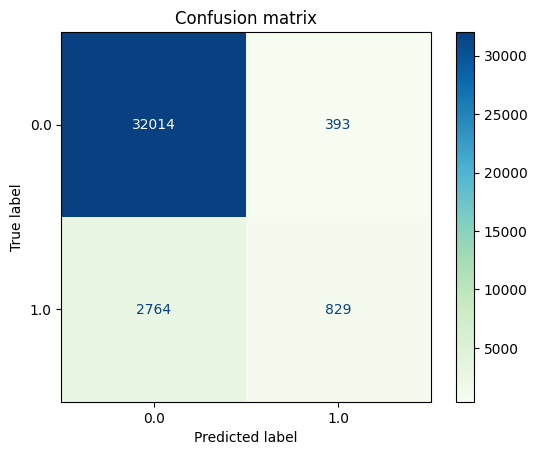

In [ ]:
metrics.ConfusionMatrixDisplay.from_predictions(
    target_test,
    target_pred,
    normalize = None,
    values_format = 'd',
    cmap = 'GnBu',
    )
plt.grid(False)
plt.title('Confusion matrix')

The model predicts class 0 very well and correctly identifies most negatives. However, it performs poorly on class 1, missing many positives. This happens because the dataset is highly imbalanced, with class 0 greatly outnumbering class 1. Although overall accuracy is high, true positive detection remains weak.



## Rebalancing the Training Data

The next best step is to balance the dataset and refit/retrain the model. We will first make a new backup, then split the training data into two new dataframes. We will then count how many rows are in the smaller group, then randomly sample that same number from the bigger group. After, combine them back together and shuffle the result for a 50/50 training set.

### Undersample Majority Class

In [ ]:
train_df = features_train.copy()
train_df["target"] = target_train.values

train_0 = train_df[train_df["target"] == 0]
train_1 = train_df[train_df["target"] == 1]

print("Class 0 rows:", len(train_0))
print("Class 1 rows:", len(train_1))

Class 0 rows: 129553
Class 1 rows: 14447


### Create Balanced Training Set

The minority class count was used as the sampling size so the majority class could be reduced to the same number of rows before combining both groups.

In [ ]:
n = train_1.shape[0]

In [ ]:
train_0_downsampled = train_0.sample(n=n, random_state=42)
print("Downsampled class 0 rows:", len(train_0_downsampled))

Downsampled class 0 rows: 14447


The downsampled majority class was combined with the full minority class and shuffled, creating a balanced training set with equal class representation.

In [ ]:
train_balanced = pd.concat([train_0_downsampled, train_1], axis=0)
train_balanced = train_balanced.sample(frac=1, random_state=42)

train_balanced["target"].value_counts()

,count
target,
0.0,14447
1.0,14447


The downsampled majority class and full minority class were combined and shuffled to create a balanced training set with equal representation of both classes.

### Retrain Gaussian Naive Bayes

In [ ]:
features_train_bal = train_balanced.drop(columns=["target"])
target_train_bal = train_balanced["target"]

gnb_bal = GaussianNB()
gnb_bal.fit(features_train_bal, target_train_bal);

The Gaussian Naive Bayes model was retrained using the balanced training set so it could learn from equal representation of both classes.

### Generate Balanced Predictions

In [ ]:
target_pred_bal = gnb_bal.predict(features_test)
print(target_pred_bal[:20])

[0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0.]


Predictions were generated on the original test set so the balanced model could be compared fairly against the initial model.

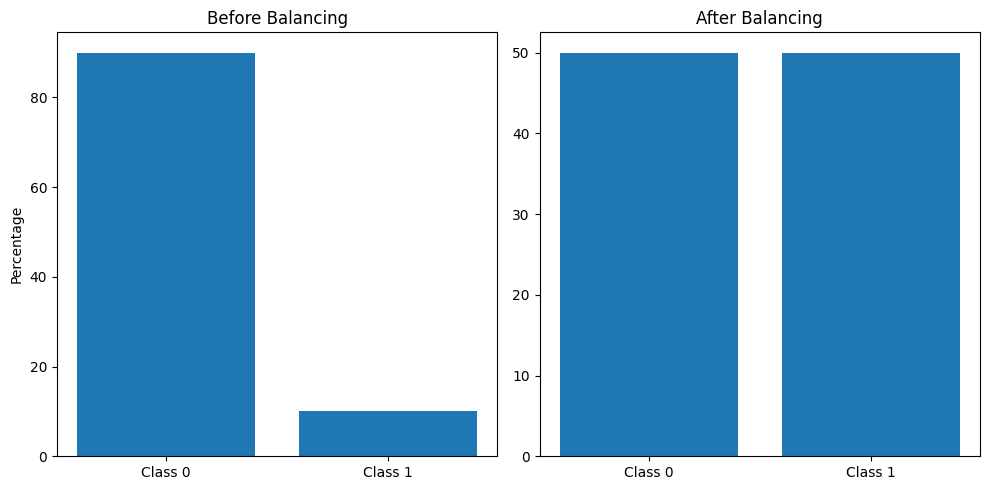

In [ ]:
# Counts
before = [90, 10]
after = [50, 50]

labels = ["Class 0", "Class 1"]

fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Before balancing
axes[0].bar(labels, before)
axes[0].set_title("Before Balancing")
axes[0].set_ylabel("Percentage")

# After balancing
axes[1].bar(labels, after)
axes[1].set_title("After Balancing")

plt.tight_layout()
plt.show()

Create new train sets with the balanced dataset and fit the GNB model with new train sets

In [ ]:
features_train = train_balanced.drop(columns=["target"])
target_train = train_balanced["target"]

In [ ]:
features_test = df.drop(columns=["target"])
target_test = df["target"]

In [ ]:
model = GaussianNB()
model.fit(features_train, target_train)

GaussianNB()

## Balanced Model Evaluation





In [ ]:
predictions = model.predict(features_test)

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(target_test, predictions)

array([[124489,  37471],
       [  4627,  13413]])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(target_test, predictions))

              precision    recall  f1-score   support

         0.0       0.96      0.77      0.86    161960
         1.0       0.26      0.74      0.39     18040

    accuracy                           0.77    180000
   macro avg       0.61      0.76      0.62    180000
weighted avg       0.89      0.77      0.81    180000



### Confusion Matrix After Balancing

### Report Accuracy after Balancing

### Classifcation Report After Balancing

## Data Visualization

The side-by-side confusion matrices show how balancing changed model behavior. Before balancing, the model correctly identified most non-purchase cases but missed many actual purchases, producing very low recall for class 1. After balancing, true positive predictions increased substantially, meaning the model became much better at detecting actual purchases, although false positives also increased. This reflects the expected tradeoff: lower overall precision, but much stronger sensitivity to the minority class.

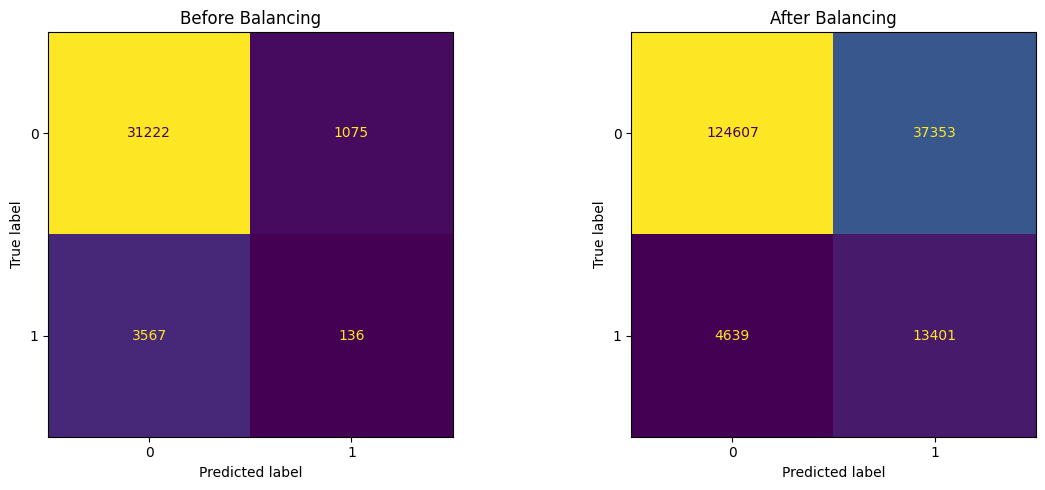

In [ ]:
# side-by-side visualization of confusion matrices before and after balancing dataset

# Convert to numpy arrays
cm_before = np.array([[31222, 1075],
                      [3567, 136]])

cm_after = np.array([[124607, 37353],
                     [4639, 13401]])

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before balancing
ConfusionMatrixDisplay(confusion_matrix=cm_before, display_labels=["0", "1"]).plot(
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Before Balancing")

# After balancing
ConfusionMatrixDisplay(confusion_matrix=cm_after, display_labels=["0", "1"]).plot(
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("After Balancing")

plt.tight_layout()
plt.show()

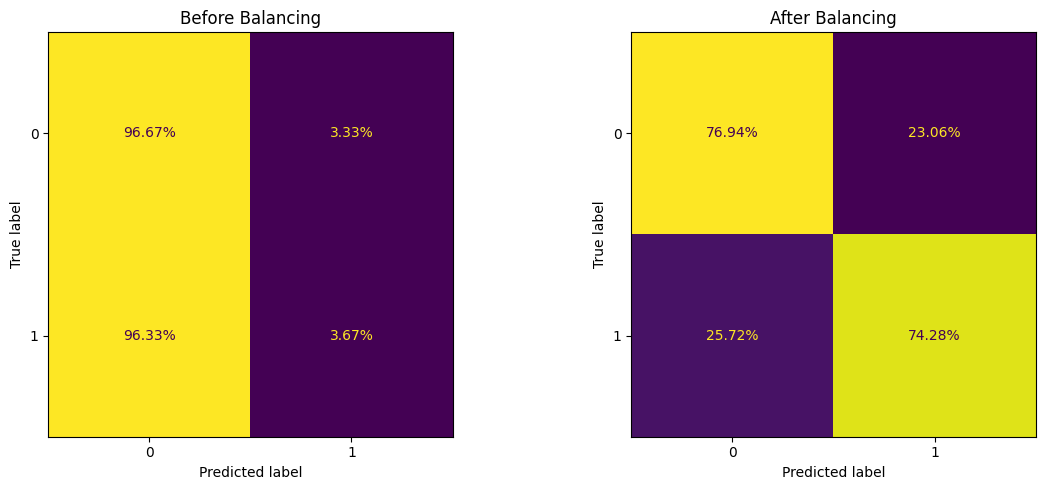

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays
cm_before = np.array([[31222, 1075],
                      [3567, 136]])

cm_after = np.array([[124607, 37353],
                     [4639, 13401]])

# Normalize by row (true labels)
cm_before_norm = cm_before.astype('float') / cm_before.sum(axis=1)[:, np.newaxis]
cm_after_norm = cm_after.astype('float') / cm_after.sum(axis=1)[:, np.newaxis]

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before balancing
ConfusionMatrixDisplay(confusion_matrix=cm_before_norm, display_labels=["0", "1"]).plot(
    ax=axes[0],
    colorbar=False,
    values_format=".2%"
)
axes[0].set_title("Before Balancing")

# After balancing
ConfusionMatrixDisplay(confusion_matrix=cm_after_norm, display_labels=["0", "1"]).plot(
    ax=axes[1],
    colorbar=False,
    values_format=".2%"
)
axes[1].set_title("After Balancing")

plt.tight_layout()
plt.show()

The increase from 136 to 13,401 true positives demonstrates how balancing dramatically improved minority-class detection.

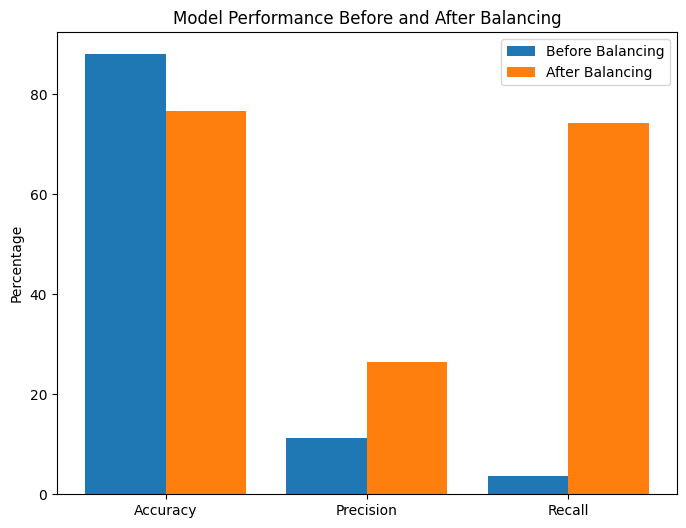

In [ ]:

metrics = ["Accuracy", "Precision", "Recall"]
before = [88, 11.2, 3.7]
after = [76.7, 26.4, 74.3]

x = range(len(metrics))

plt.figure(figsize=(8,6))

plt.bar(x, before, width=0.4, label="Before Balancing")
plt.bar([i + 0.4 for i in x], after, width=0.4, label="After Balancing")

plt.xticks([i + 0.2 for i in x], metrics)
plt.ylabel("Percentage")
plt.title("Model Performance Before and After Balancing")
plt.legend()

plt.show()

## Conclusion

This project made it clear that a model can look strong on paper while still missing what matters most. Before balancing, the model had high accuracy but rarely detected successful transactions. After balancing the training data, it became much better at identifying successful transactions, though it also produced more false positives. That tradeoff showed me that model evaluation has to go beyond accuracy and include how well the model handles the different categories within the class we actually care about, which is the target.